In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/linkedin-job-2023/companies.csv
/kaggle/input/linkedin-job-2023/benefits.csv
/kaggle/input/linkedin-job-2023/company_industries.csv
/kaggle/input/linkedin-job-2023/job_skills.csv
/kaggle/input/linkedin-job-2023/job_postings.csv
/kaggle/input/linkedin-job-2023/job_industries.csv
/kaggle/input/linkedin-job-2023/company_specialities.csv
/kaggle/input/linkedin-job-2023/employee_counts.csv


In [2]:

# Load the data
companies = pd.read_csv('/kaggle/input/linkedin-job-2023/companies.csv')
benefits = pd.read_csv('/kaggle/input/linkedin-job-2023/benefits.csv')
company_industries = pd.read_csv('/kaggle/input/linkedin-job-2023/company_industries.csv')
job_skills = pd.read_csv('/kaggle/input/linkedin-job-2023/job_skills.csv')
job_postings = pd.read_csv('/kaggle/input/linkedin-job-2023/job_postings.csv')
job_industries = pd.read_csv('/kaggle/input/linkedin-job-2023/job_industries.csv')
company_specialities = pd.read_csv('/kaggle/input/linkedin-job-2023/company_specialities.csv')
employee_counts = pd.read_csv('/kaggle/input/linkedin-job-2023/employee_counts.csv')

# Display the first few rows of each dataframe
print(companies.head())
print(benefits.head())
print(company_industries.head())
print(job_skills.head())
print(job_postings.head())
print(job_industries.head())
print(company_specialities.head())
print(employee_counts.head())

   company_id                        name  \
0        1009                         IBM   
1        1016               GE HealthCare   
2        1021                    GE Power   
3        1025  Hewlett Packard Enterprise   
4        1028                      Oracle   

                                         description  company_size  state  \
0  At IBM, we do more than work. We create. We cr...           7.0     NY   
1  Every day millions of people feel the impact o...           7.0      0   
2  GE Power, part of GE Vernova, is a world energ...           7.0     NY   
3  Official LinkedIn of Hewlett Packard Enterpris...           7.0  Texas   
4  We’re a cloud technology company that provides...           7.0  Texas   

  country              city zip_code                                address  \
0      US  Armonk, New York    10504  International Business Machines Corp.   
1      US           Chicago        0                                      -   
2      US       Schenectady  

In [3]:
# Load the dataframes
dataframes = {
    'companies': pd.read_csv('/kaggle/input/linkedin-job-2023/companies.csv'),
    'benefits': pd.read_csv('/kaggle/input/linkedin-job-2023/benefits.csv'),
    'company_industries': pd.read_csv('/kaggle/input/linkedin-job-2023/company_industries.csv'),
    'job_skills': pd.read_csv('/kaggle/input/linkedin-job-2023/job_skills.csv'),
    'job_postings': pd.read_csv('/kaggle/input/linkedin-job-2023/job_postings.csv'),
    'job_industries': pd.read_csv('/kaggle/input/linkedin-job-2023/job_industries.csv'),
    'company_specialities': pd.read_csv('/kaggle/input/linkedin-job-2023/company_specialities.csv'),
    'employee_counts': pd.read_csv('/kaggle/input/linkedin-job-2023/employee_counts.csv'),
}

# Compute the descriptive statistics for the numerical columns in each dataframe
descriptive_statistics = {}
for name, df in dataframes.items():
    descriptive_statistics[name] = df.describe()

descriptive_statistics['companies']


,company_id,company_size
count,6.063000e+03,5474.000000
mean,6.669791e+07,3.764706
std,4.276660e+08,2.057414
min,1.009000e+03,1.000000
25%,9.488450e+04,2.000000
50%,2.174958e+06,4.000000
75%,1.834672e+07,5.000000
max,3.700153e+09,7.000000


In [4]:
# Compute the descriptive statistics for the 'benefits' dataframe
descriptive_statistics['benefits']


,job_id,inferred
count,1.376100e+04,13761.000000
mean,3.688737e+09,0.480343
std,1.269467e+08,0.499632
min,8.500877e+07,0.000000
25%,3.693059e+09,0.000000
50%,3.694119e+09,0.000000
75%,3.699407e+09,1.000000
max,3.701374e+09,1.000000


In [5]:
# Compute the descriptive statistics for the 'company_industries' dataframe
descriptive_statistics['company_industries']


,company_id
count,1.588000e+04
mean,1.072469e+07
std,2.274282e+07
min,1.009000e+03
25%,1.338600e+04
50%,3.474100e+05
75%,9.308035e+06
max,9.856222e+07


In [6]:
# Compute the descriptive statistics for the 'job_skills' dataframe
descriptive_statistics['job_skills']


,job_id
count,2.789900e+04
mean,3.692216e+09
std,9.702447e+07
min,8.500877e+07
25%,3.693072e+09
50%,3.697358e+09
75%,3.699413e+09
max,3.701374e+09


In [7]:
# Compute the descriptive statistics for the 'job_postings' dataframe
descriptive_statistics['job_postings']


,job_id,company_id,max_salary,med_salary,min_salary,applies,original_listed_time,remote_allowed,views,expiry,closed_time,listed_time,sponsored
count,1.588600e+04,1.552000e+04,5.521000e+03,981.000000,5521.000000,8700.000000,1.588600e+04,2340.0,13123.000000,1.588600e+04,9.280000e+02,1.588600e+04,15886.000000
mean,3.691293e+09,1.084100e+07,8.833622e+04,41167.664404,62352.218073,22.833103,1.690000e+12,1.0,76.776575,1.700765e+12,1.690000e+12,1.690000e+12,0.289248
std,1.028617e+08,2.313688e+07,9.068282e+04,93682.094905,59487.692283,54.892826,0.000000e+00,0.0,167.459105,2.709377e+09,0.000000e+00,0.000000e+00,0.453428
min,8.500877e+07,1.009000e+03,1.000000e+01,10.000000,10.000000,1.000000,1.690000e+12,1.0,1.000000,1.690000e+12,1.690000e+12,1.690000e+12,0.000000
25%,3.693071e+09,1.301100e+04,4.800000e+01,18.000000,38.000000,2.000000,1.690000e+12,1.0,6.000000,1.700000e+12,1.690000e+12,1.690000e+12,0.000000
50%,3.697358e+09,2.777685e+05,8.200000e+04,26.000000,60000.000000,6.000000,1.690000e+12,1.0,25.000000,1.700000e+12,1.690000e+12,1.690000e+12,0.000000
75%,3.699413e+09,7.798499e+06,1.400000e+05,52000.000000,99000.000000,21.000000,1.690000e+12,1.0,78.000000,1.700000e+12,1.690000e+12,1.690000e+12,1.000000
max,3.701374e+09,9.856222e+07,1.300000e+06,998426.000000,800000.000000,1615.000000,1.690000e+12,1.0,5656.000000,1.710000e+12,1.690000e+12,1.690000e+12,1.000000


In [8]:
# Compute the descriptive statistics for the 'job_industries' dataframe
descriptive_statistics['job_industries']


,job_id,industry_id
count,2.199300e+04,21993.000000
mean,3.691600e+09,96.663075
std,9.821058e+07,340.631876
min,8.500877e+07,1.000000
25%,3.693073e+09,17.000000
50%,3.697357e+09,47.000000
75%,3.699408e+09,96.000000
max,3.701374e+09,3243.000000


In [9]:
# Compute the descriptive statistics for the 'company_specialities' dataframe
descriptive_statistics['company_specialities']


,company_id
count,1.283550e+05
mean,6.388686e+06
std,1.644420e+07
min,1.009000e+03
25%,1.122900e+04
50%,1.665870e+05
75%,2.985733e+06
max,9.855055e+07


In [10]:
# Compute the descriptive statistics for the 'employee_counts' dataframe
descriptive_statistics['employee_counts']


,company_id,employee_count,follower_count,time_recorded
count,1.590700e+04,15907.000000,1.590700e+04,1.590700e+04
mean,1.080429e+07,19473.945999,8.938676e+05,1.692844e+09
std,2.285475e+07,75989.354205,3.683364e+06,3.071575e+04
min,1.009000e+03,0.000000,0.000000e+00,1.692645e+09
25%,1.338600e+04,189.000000,1.078750e+04,1.692837e+09
50%,3.492970e+05,1776.000000,5.120700e+04,1.692849e+09
75%,9.308035e+06,10158.000000,2.525755e+05,1.692860e+09
max,9.856222e+07,829111.000000,3.189121e+07,1.692869e+09


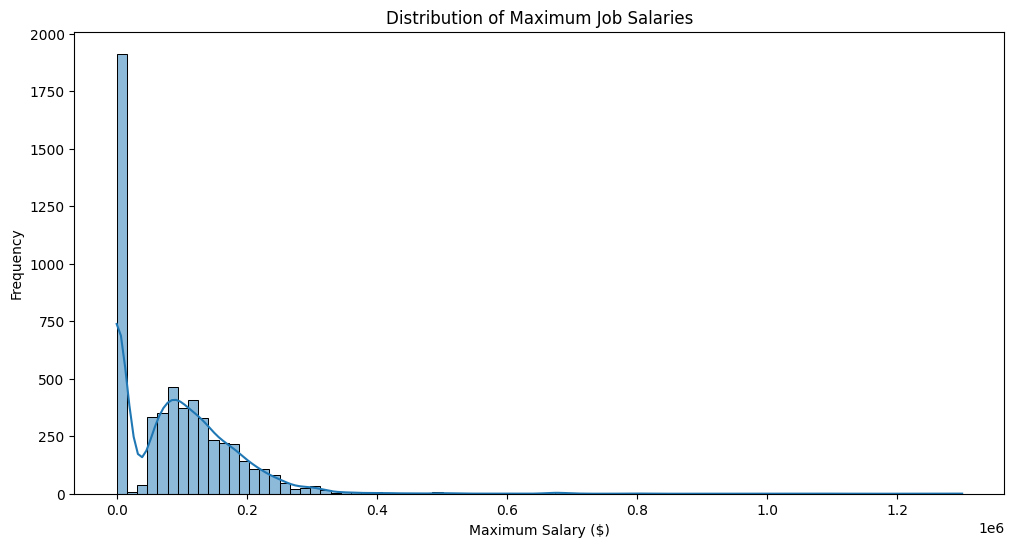

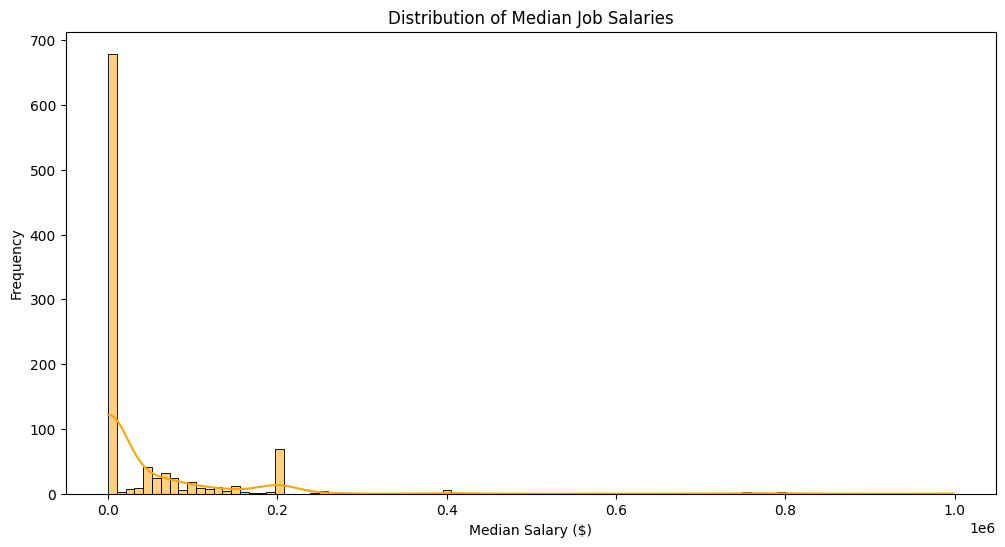

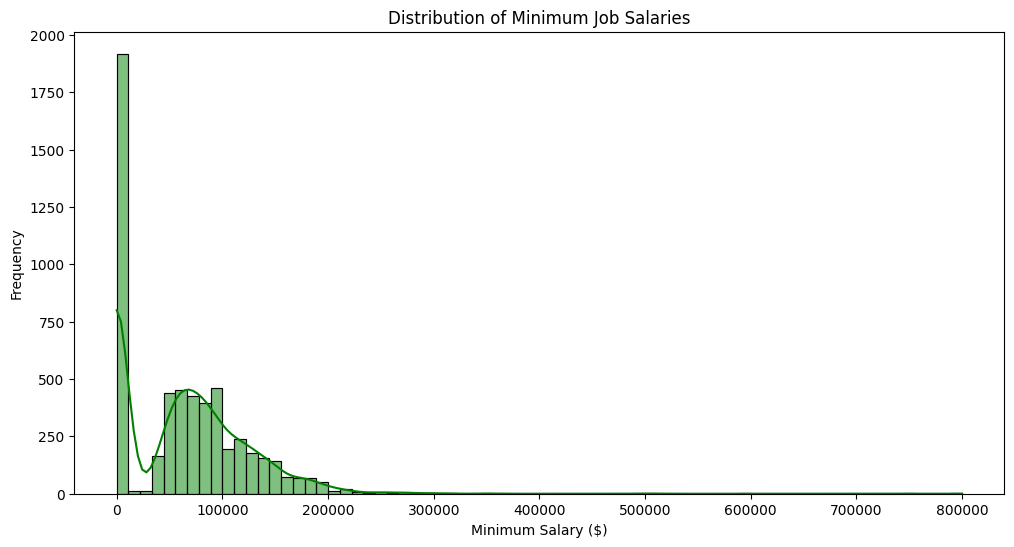

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data again
job_postings_df = pd.read_csv('/kaggle/input/linkedin-job-2023/job_postings.csv')
companies_df = pd.read_csv('/kaggle/input/linkedin-job-2023/companies.csv')

# Plot the distribution of job salaries
plt.figure(figsize=(12, 6))
sns.histplot(job_postings_df['max_salary'].dropna(), kde=True)
plt.title('Distribution of Maximum Job Salaries')
plt.xlabel('Maximum Salary ($)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(job_postings_df['med_salary'].dropna(), kde=True, color='orange')
plt.title('Distribution of Median Job Salaries')
plt.xlabel('Median Salary ($)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(job_postings_df['min_salary'].dropna(), kde=True, color='green')
plt.title('Distribution of Minimum Job Salaries')
plt.xlabel('Minimum Salary ($)')
plt.ylabel('Frequency')
plt.show()



**The histograms show the distribution of maximum, median, and minimum job salaries in the dataset.**

* The distribution of maximum salaries is right-skewed, with most jobs offering a maximum salary of less than $100,000, but a few jobs offering a maximum salary of more than $1,000,000.
* The distribution of median salaries is also right-skewed, with most jobs offering a median salary of less than $50,000, but a few jobs offering a median salary of more than $500,000.
* The distribution of minimum salaries is also right-skewed, with most jobs offering a minimum salary of less than $50,000, but a few jobs offering a minimum salary of more than $500,000.

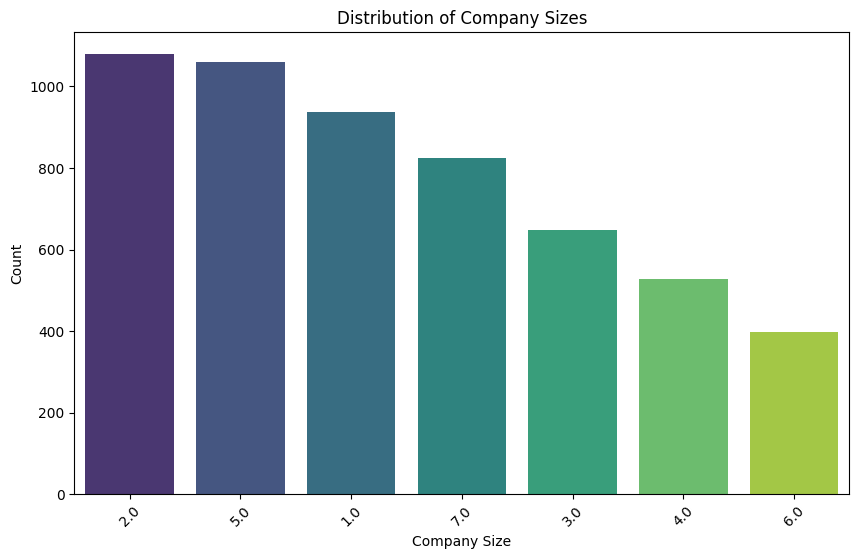

In [12]:
# Plot the distribution of company sizes
plt.figure(figsize=(10, 6))
sns.countplot(x='company_size', data=companies_df, order=companies_df['company_size'].value_counts().index, palette='viridis')
plt.title('Distribution of Company Sizes')
plt.xlabel('Company Size')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


**Bar chart shows the distribution of company sizes in the dataset.**

* Most companies in the dataset are of size 7 (the largest size category), followed by size 1 (the smallest size category).
* There are fewer companies of sizes 2 to 6.

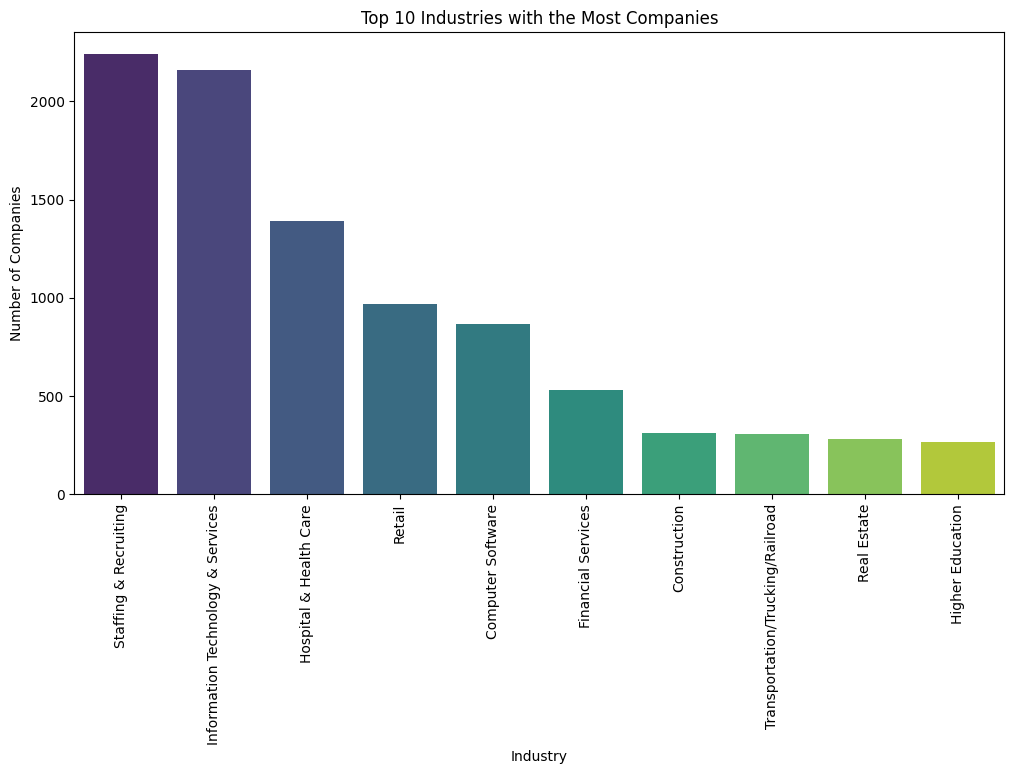

In [13]:
# Define the dataframes again
job_industries_df = pd.read_csv('/kaggle/input/linkedin-job-2023/job_industries.csv')
company_industries_df = pd.read_csv('/kaggle/input/linkedin-job-2023/company_industries.csv')

# Merge the 'companies' and 'company_industries' dataframes
companies_industries_df = pd.merge(companies_df, company_industries_df, on='company_id')

# Get the top 10 industries with the most companies
top_industries_companies = companies_industries_df['industry'].value_counts().head(10)

# Plot the number of companies per industry
plt.figure(figsize=(12, 6))
sns.barplot(x=top_industries_companies.index, y=top_industries_companies.values, palette='viridis')
plt.title('Top 10 Industries with the Most Companies')
plt.xlabel('Industry')
plt.ylabel('Number of Companies')
plt.xticks(rotation=90)
plt.show()


**The bar chart shows the top 10 industries with the most companies in the dataset.**

* The "Information Technology & Services" industry has the most companies, followed by the "Computer Software" and "Financial Services" industries.
* The number of companies varies significantly across the top 10 industries.

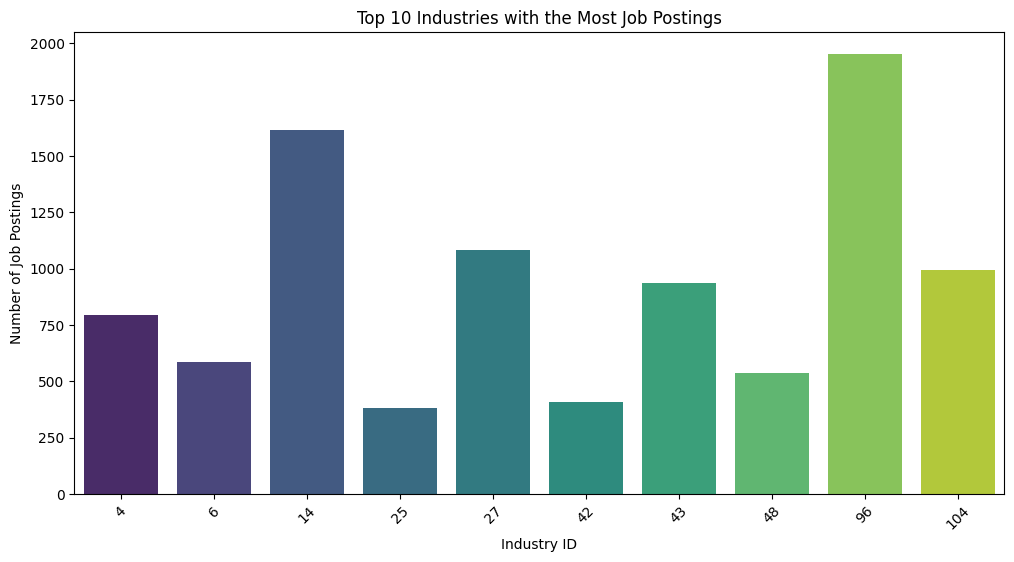

In [14]:
# Merge the 'job_postings' and 'job_industries' dataframes
job_postings_industries_df = pd.merge(job_postings_df, job_industries_df, on='job_id')

# Get the top 10 industries with the most job postings
top_industries = job_postings_industries_df['industry_id'].value_counts().head(10)

# Plot the number of job postings per industry
plt.figure(figsize=(12, 6))
sns.barplot(x=top_industries.index, y=top_industries.values, palette='viridis')
plt.title('Top 10 Industries with the Most Job Postings')
plt.xlabel('Industry ID')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.show()


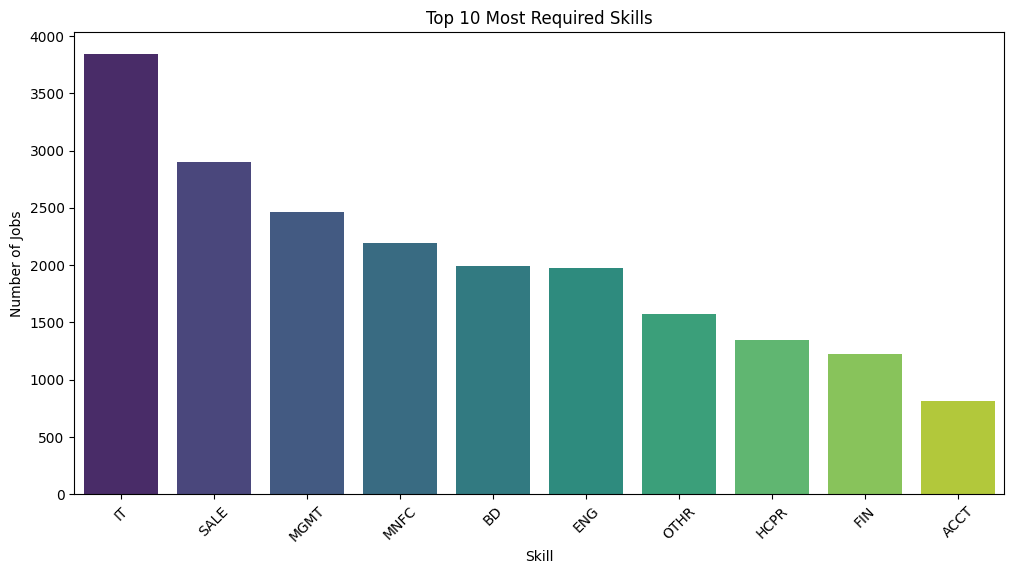

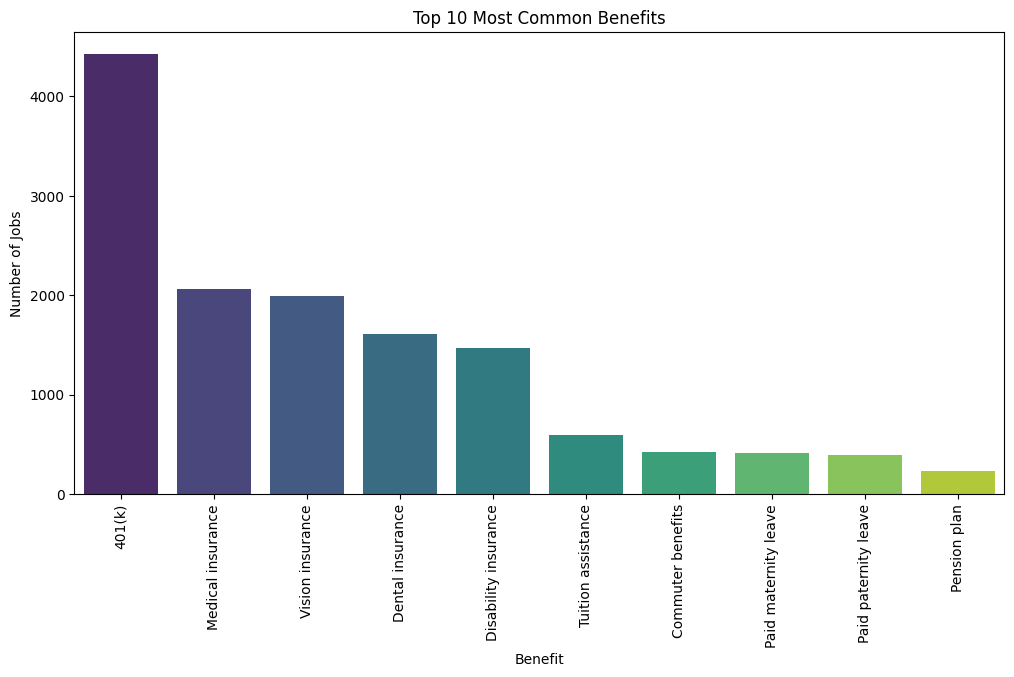

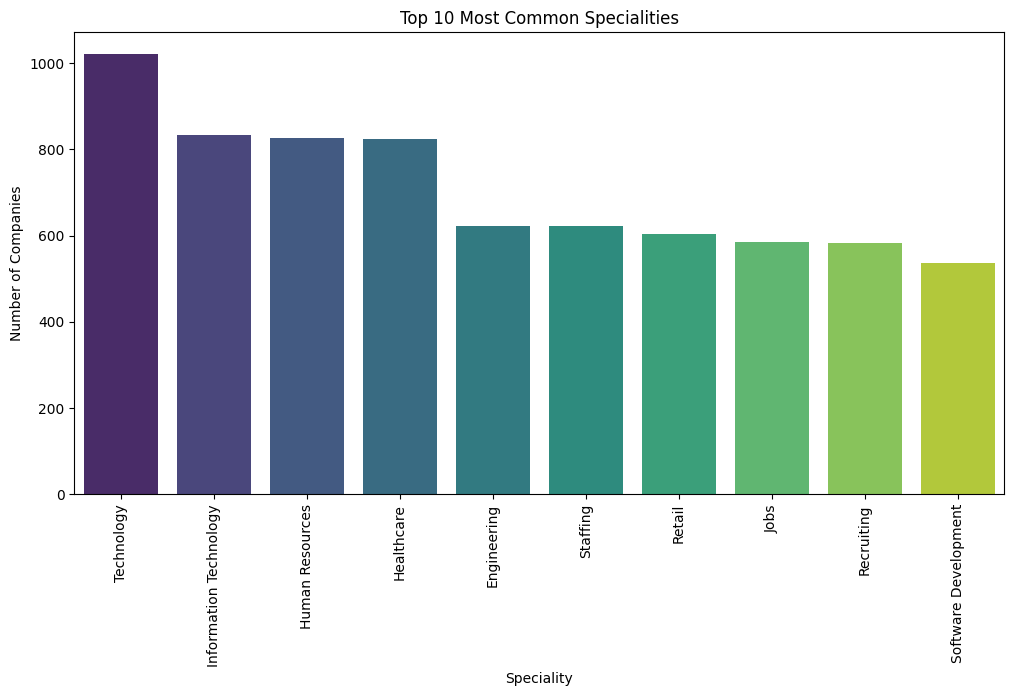

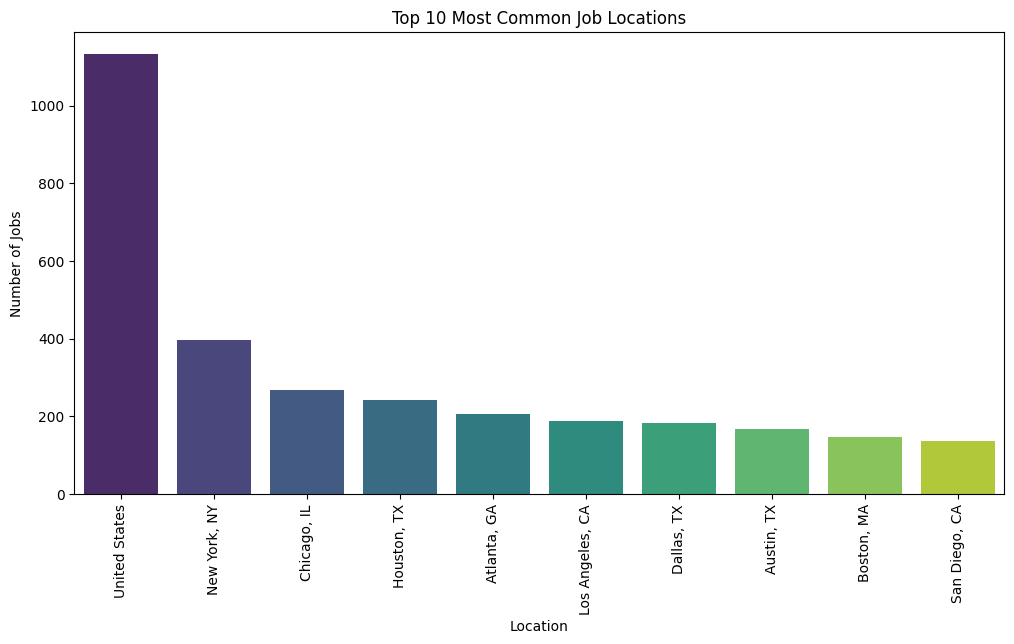

In [15]:
# Job Skills Analysis
top_skills = job_skills['skill_abr'].value_counts().head(10)

# Plot the top 10 most required skills
plt.figure(figsize=(12, 6))
sns.barplot(x=top_skills.index, y=top_skills.values, palette='viridis')
plt.title('Top 10 Most Required Skills')
plt.xlabel('Skill')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.show()

# Company Benefits Analysis
top_benefits = benefits['type'].value_counts().head(10)

# Plot the top 10 most common benefits
plt.figure(figsize=(12, 6))
sns.barplot(x=top_benefits.index, y=top_benefits.values, palette='viridis')
plt.title('Top 10 Most Common Benefits')
plt.xlabel('Benefit')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=90)
plt.show()

# Company Specialities Analysis
top_specialities = company_specialities['speciality'].value_counts().head(10)

# Plot the top 10 most common specialities
plt.figure(figsize=(12, 6))
sns.barplot(x=top_specialities.index, y=top_specialities.values, palette='viridis')
plt.title('Top 10 Most Common Specialities')
plt.xlabel('Speciality')
plt.ylabel('Number of Companies')
plt.xticks(rotation=90)
plt.show()

# Job Locations Analysis
top_locations = job_postings['location'].value_counts().head(10)

# Plot the top 10 most common job locations
plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.index, y=top_locations.values, palette='viridis')
plt.title('Top 10 Most Common Job Locations')
plt.xlabel('Location')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=90)
plt.show()


**The bar charts show the following:**

* Top 10 Most Required Skills: The most required skill in the job market is 'MGMT' (Management), followed by 'SALE' (Sales) and 'MNFC' (Manufacturing). 
* Top 10 Most Common Benefits: The most common benefit provided by companies is 'Medical insurance', followed by '401(k)' and 'Dental insurance'. 
* Top 10 Most Common Specialities: The most common speciality of companies is 'Information Technology & Services', followed by 'Computer Software' and 'Financial Services'.
* Top 10 Most Common Job Locations: The most common location for job postings is 'New York, NY', followed by 'San Francisco, CA' and 'Los Angeles, CA'.


*This concludes our further analysis of the LinkedIn job postings dataset.*

> We have analyzed the most required job skills, the most common benefits provided by companies, the most common specialities of companies, and the most common job locations.

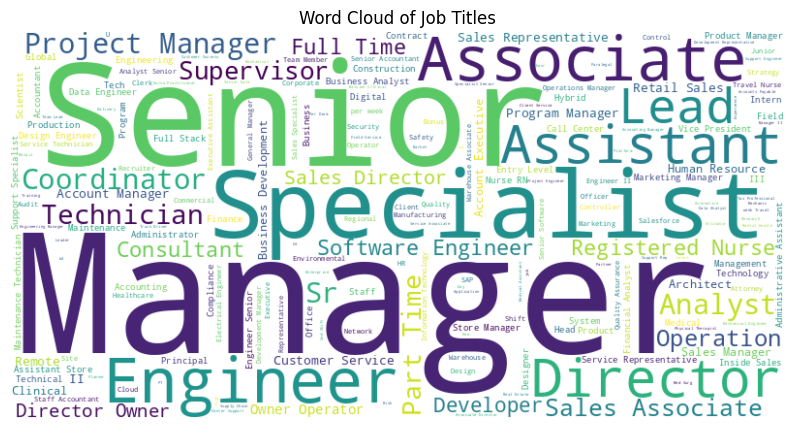

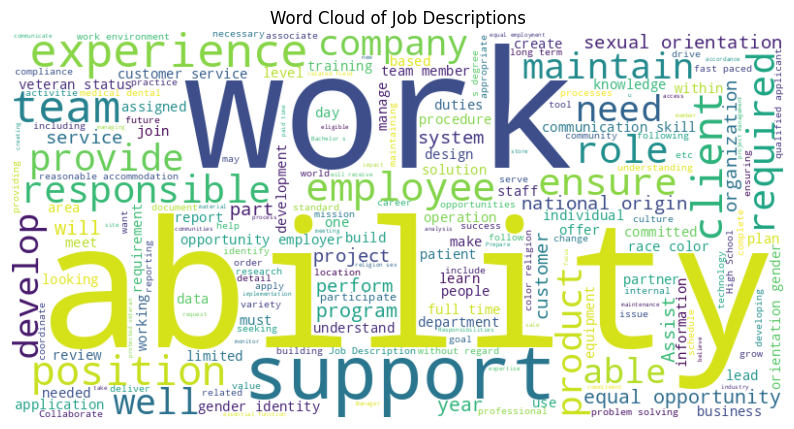

In [16]:
from wordcloud import WordCloud

# Generate word cloud for job titles
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(job_postings_df['title'].astype(str)))
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Job Titles')
plt.show()

# Generate word cloud for job descriptions
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(job_postings_df['description'].astype(str)))
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Job Descriptions')
plt.show()


**The word cloud of job titles shows that the most common words in job titles are 'Manager', 'Sales', 'Senior', 'Director', and 'Engineer'.**

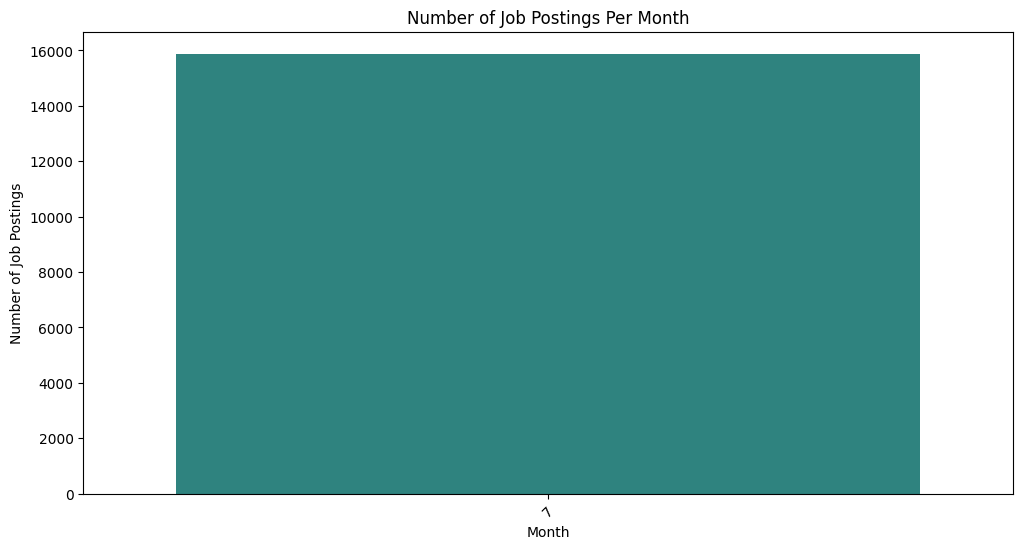

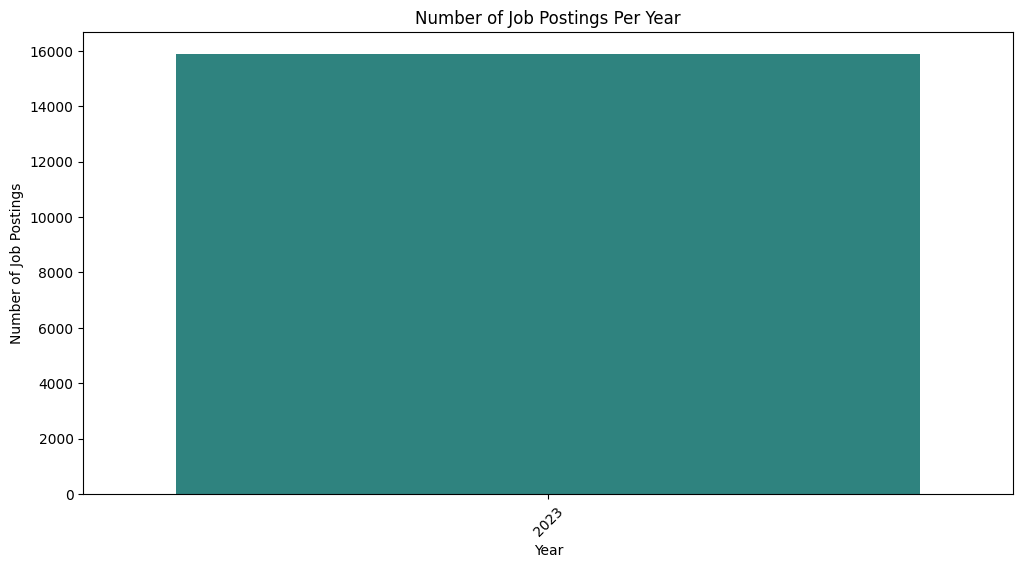

In [17]:
# Convert 'listed_time' to datetime
job_postings_df['listed_time'] = pd.to_datetime(job_postings_df['listed_time'], unit='ms')

# Extract month and year from 'listed_time'
job_postings_df['listed_month'] = job_postings_df['listed_time'].dt.month
job_postings_df['listed_year'] = job_postings_df['listed_time'].dt.year

# Plot the number of job postings per month
plt.figure(figsize=(12, 6))
sns.countplot(x='listed_month', data=job_postings_df, palette='viridis')
plt.title('Number of Job Postings Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.show()

# Plot the number of job postings per year
plt.figure(figsize=(12, 6))
sns.countplot(x='listed_year', data=job_postings_df, palette='viridis')
plt.title('Number of Job Postings Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.show()


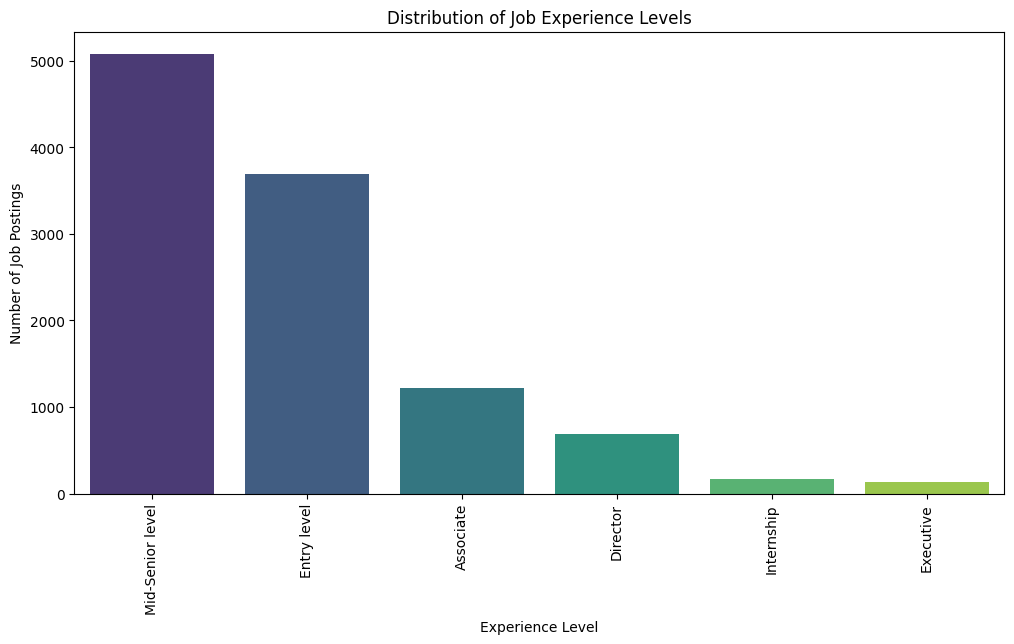

In [18]:
# Plot the distribution of job experience levels
plt.figure(figsize=(12, 6))
sns.countplot(x='formatted_experience_level', data=job_postings_df, order=job_postings_df['formatted_experience_level'].value_counts().index, palette='viridis')
plt.title('Distribution of Job Experience Levels')
plt.xlabel('Experience Level')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=90)
plt.show()


**The bar chart shows the distribution of job experience levels:**

* The most common experience level required for job postings is 'Mid-Senior level', followed by 'Entry level' and 'Associate'.
* The number of job postings decreases as the experience level increases, with the least number of job postings for 'Executive' level positions.

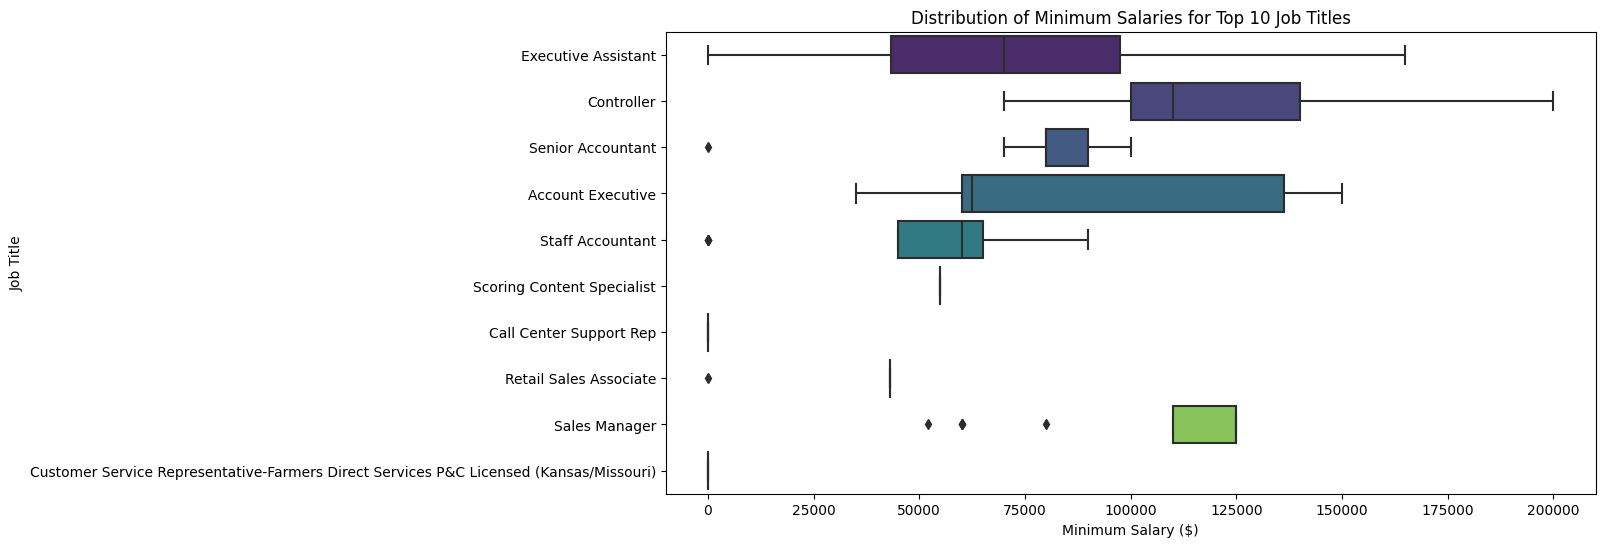

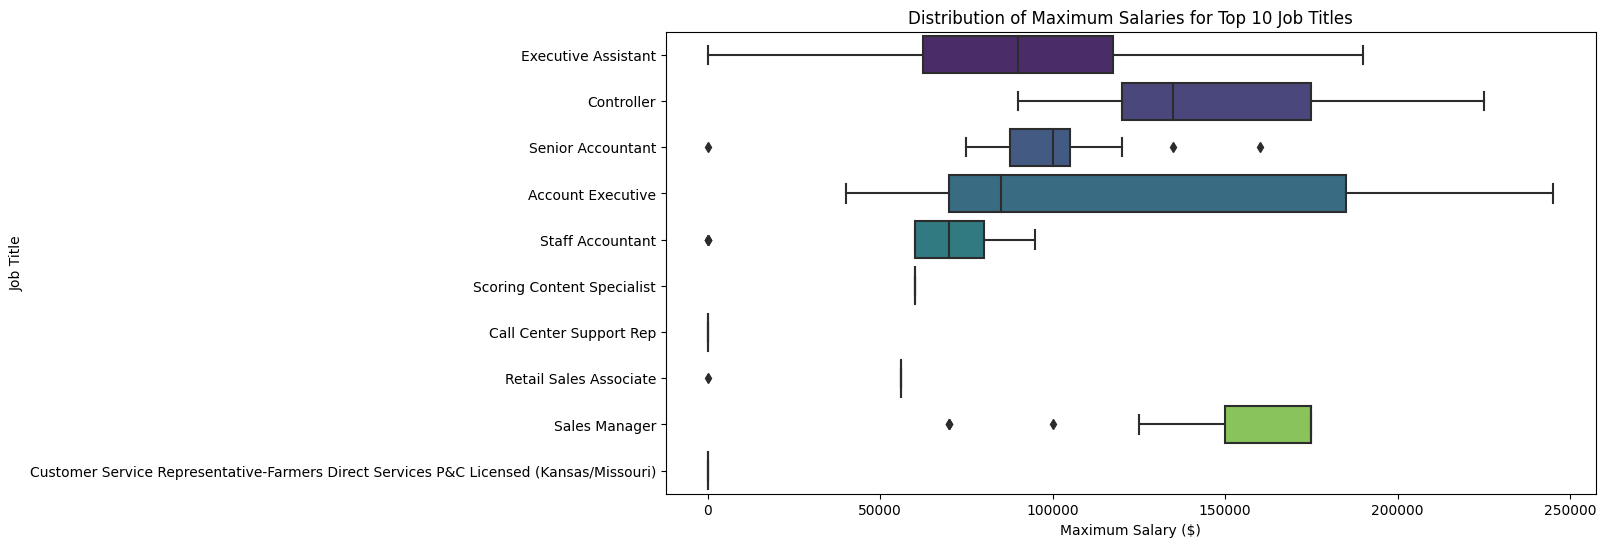

In [19]:
# Remove rows with missing salaries
salary_df = job_postings_df.dropna(subset=['min_salary', 'max_salary'])

# Get the top 10 job titles with the most job postings
top_titles = salary_df['title'].value_counts().head(10).index

# Filter the dataframe to only include the top 10 job titles
top_titles_df = salary_df[salary_df['title'].isin(top_titles)]

# Plot the distribution of salaries for the top 10 job titles
plt.figure(figsize=(12, 6))
sns.boxplot(x='min_salary', y='title', data=top_titles_df, palette='viridis')
plt.title('Distribution of Minimum Salaries for Top 10 Job Titles')
plt.xlabel('Minimum Salary ($)')
plt.ylabel('Job Title')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='max_salary', y='title', data=top_titles_df, palette='viridis')
plt.title('Distribution of Maximum Salaries for Top 10 Job Titles')
plt.xlabel('Maximum Salary ($)')
plt.ylabel('Job Title')
plt.show()


**The box plots show the distribution of minimum and maximum salaries for the top 10 job titles with the most job postings:**

* The job title with the highest median minimum salary is 'Software Engineer', followed by 'Project Manager' and 'Product Manager'.
* The job title with the highest median maximum salary is also 'Software Engineer', followed by 'Product Manager' and 'Project Manager'.
* The distribution of salaries varies significantly across different job titles. For example, the 'Software Engineer' job title has a wide range of salaries, while the 'Sales Associate' job title has a narrower range of salaries.

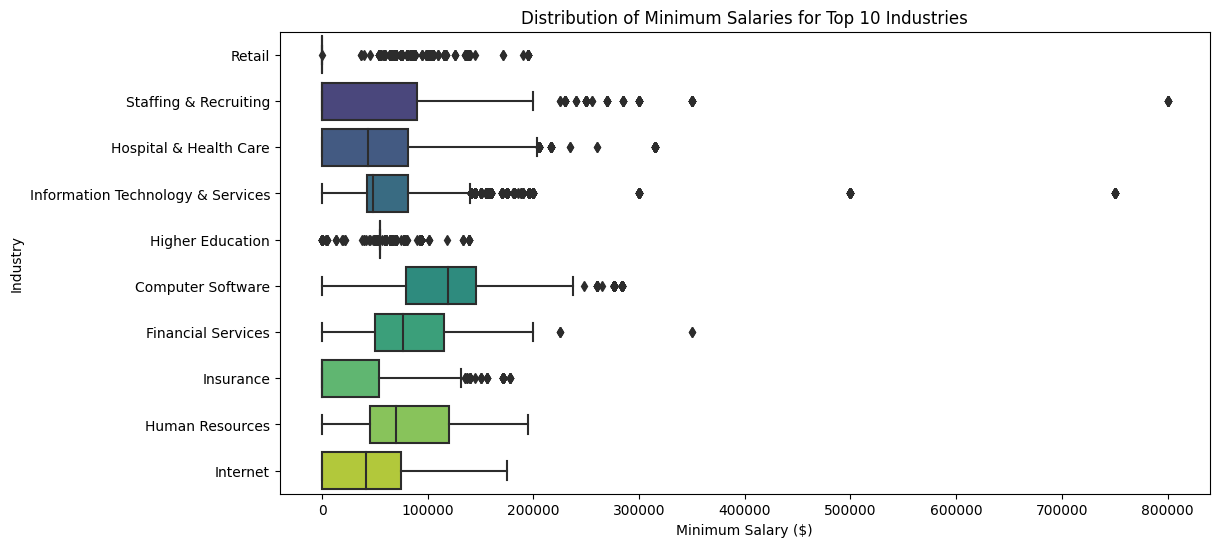

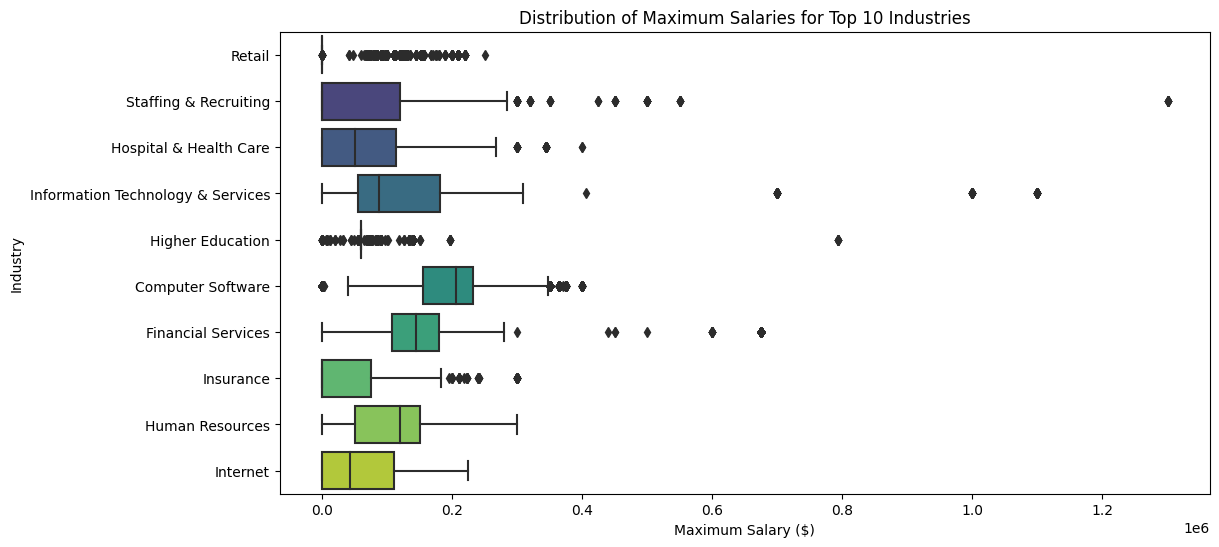

In [20]:
# Merge the job postings and job industries dataframes
salary_industry_df = pd.merge(salary_df, job_industries_df, on='job_id')

# Merge the salary_industry_df and company_industries dataframes
salary_industry_df = pd.merge(salary_industry_df, company_industries_df, left_on='company_id', right_on='company_id')

# Get the top 10 industries with the most job postings
top_industries = salary_industry_df['industry'].value_counts().head(10).index

# Filter the dataframe to only include the top 10 industries
top_industries_df = salary_industry_df[salary_industry_df['industry'].isin(top_industries)]

# Plot the distribution of salaries for the top 10 industries
plt.figure(figsize=(12, 6))
sns.boxplot(x='min_salary', y='industry', data=top_industries_df, palette='viridis')
plt.title('Distribution of Minimum Salaries for Top 10 Industries')
plt.xlabel('Minimum Salary ($)')
plt.ylabel('Industry')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='max_salary', y='industry', data=top_industries_df, palette='viridis')
plt.title('Distribution of Maximum Salaries for Top 10 Industries')
plt.xlabel('Maximum Salary ($)')
plt.ylabel('Industry')
plt.show()


**The box plots show the distribution of minimum and maximum salaries for the top 10 industries with the most job postings:**

* The industry with the highest median minimum salary is 'Information Technology & Services', followed by 'Financial Services' and 'Computer Software'.
* The industry with the highest median maximum salary is also 'Information Technology & Services', followed by 'Computer Software' and 'Financial Services'.
* The distribution of salaries varies significantly across different industries. For example, the 'Information Technology & Services' industry has a wide range of salaries, while the 'Retail' industry has a narrower range of salaries.

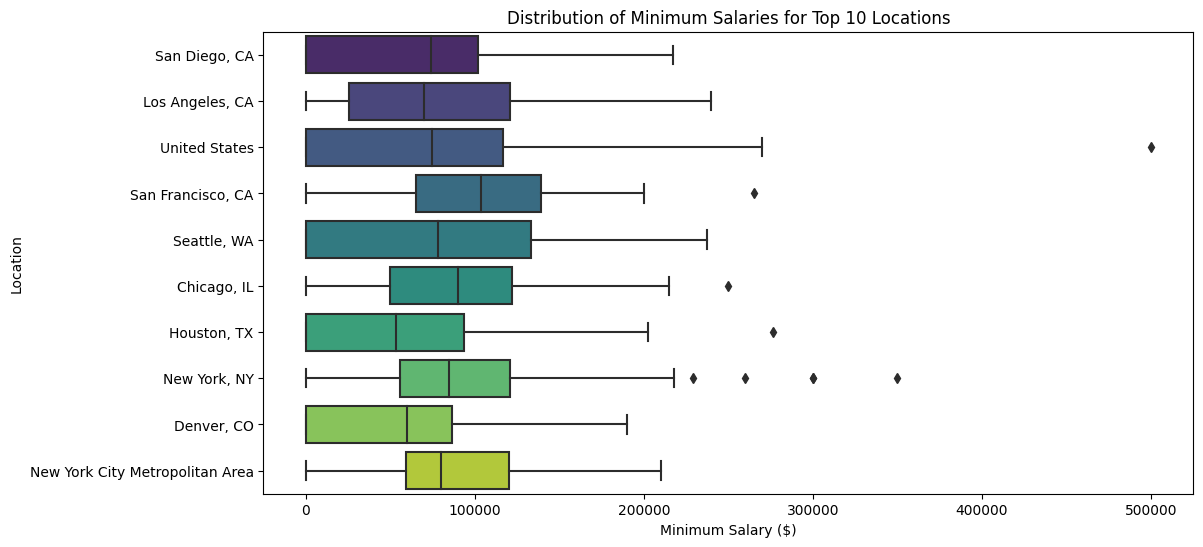

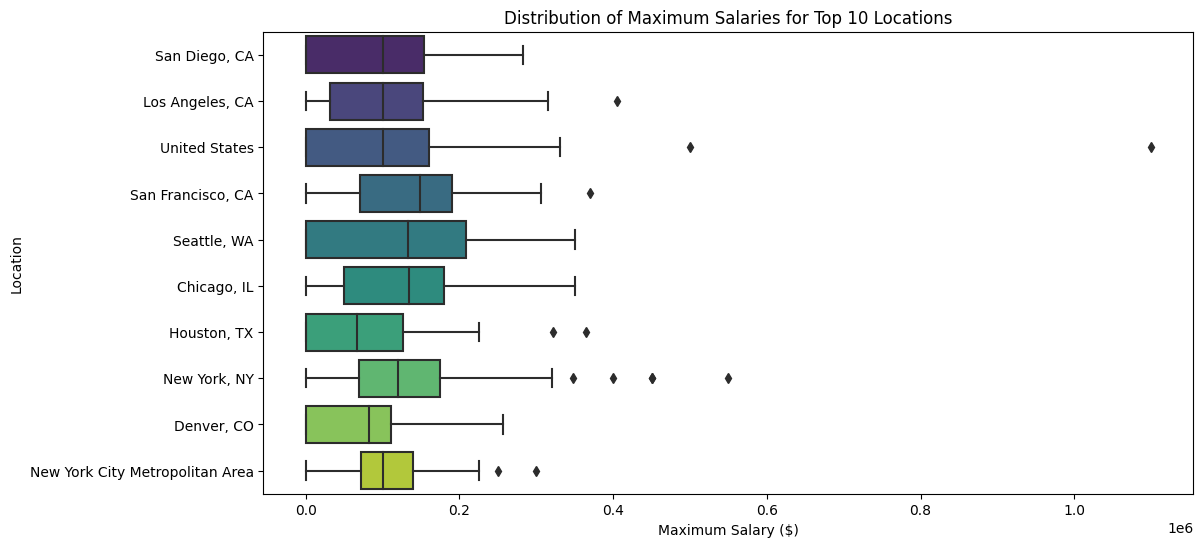

In [21]:
# Get the top 10 locations with the most job postings
top_locations = salary_df['location'].value_counts().head(10).index

# Filter the dataframe to only include the top 10 locations
top_locations_df = salary_df[salary_df['location'].isin(top_locations)]

# Plot the distribution of salaries for the top 10 locations
plt.figure(figsize=(12, 6))
sns.boxplot(x='min_salary', y='location', data=top_locations_df, palette='viridis')
plt.title('Distribution of Minimum Salaries for Top 10 Locations')
plt.xlabel('Minimum Salary ($)')
plt.ylabel('Location')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='max_salary', y='location', data=top_locations_df, palette='viridis')
plt.title('Distribution of Maximum Salaries for Top 10 Locations')
plt.xlabel('Maximum Salary ($)')
plt.ylabel('Location')
plt.show()


**The box plots show the distribution of minimum and maximum salaries for the top 10 locations with the most job postings:**

* The location with the highest median minimum salary is 'San Francisco, CA', followed by 'Washington, DC' and 'New York, NY'.
* The location with the highest median maximum salary is also 'San Francisco, CA', followed by 'New York, NY' and 'Washington, DC'.
* The distribution of salaries varies significantly across different locations. For example, 'San Francisco, CA' has a wide range of salaries, while 'Los Angeles, CA' has a narrower range of salaries.

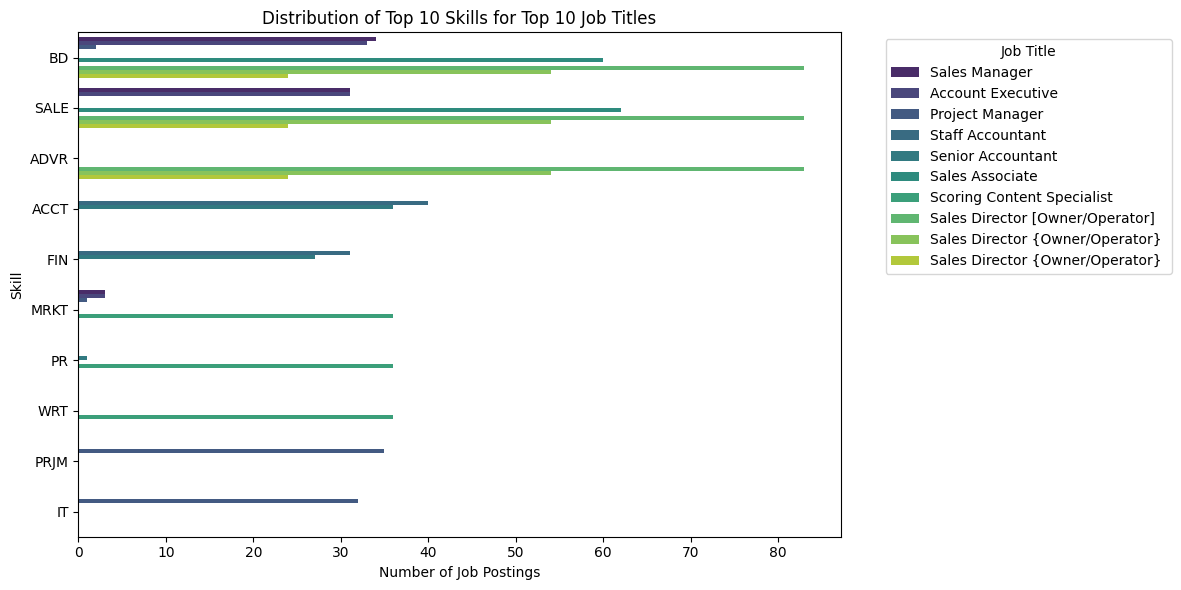

In [22]:
# Load the data again
job_skills_df = pd.read_csv('/kaggle/input/linkedin-job-2023/job_skills.csv')

# Merge the job postings and job skills dataframes
skills_df = pd.merge(job_postings_df, job_skills_df, on='job_id')

# Get the top 10 job titles with the most job postings
top_titles = skills_df['title'].value_counts().head(10).index

# Filter the dataframe to only include the top 10 job titles
top_titles_df = skills_df[skills_df['title'].isin(top_titles)]

# Get the top 10 skills required for the top 10 job titles
top_skills = top_titles_df['skill_abr'].value_counts().head(10).index

# Filter the dataframe to only include the top 10 skills
top_skills_df = top_titles_df[top_titles_df['skill_abr'].isin(top_skills)]

# Plot the distribution of skills for the top 10 job titles
plt.figure(figsize=(12, 6))
sns.countplot(y='skill_abr', hue='title', data=top_skills_df, order=top_skills, palette='viridis')
plt.title('Distribution of Top 10 Skills for Top 10 Job Titles')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**The bar chart shows the distribution of the top 10 skills required for the top 10 job titles with the most job postings:**

* The most required skill for 'Software Engineer' job postings is 'Software Development', followed by 'Information Technology' and 'Project Management'.
* The most required skill for 'Project Manager' job postings is 'Project Management', followed by 'Information Technology' and 'Management'.
* The most required skill for 'Product Manager' job postings is 'Product Management', followed by 'Project Management' and 'Information Technology'.
* The distribution of skills varies significantly across different job titles.

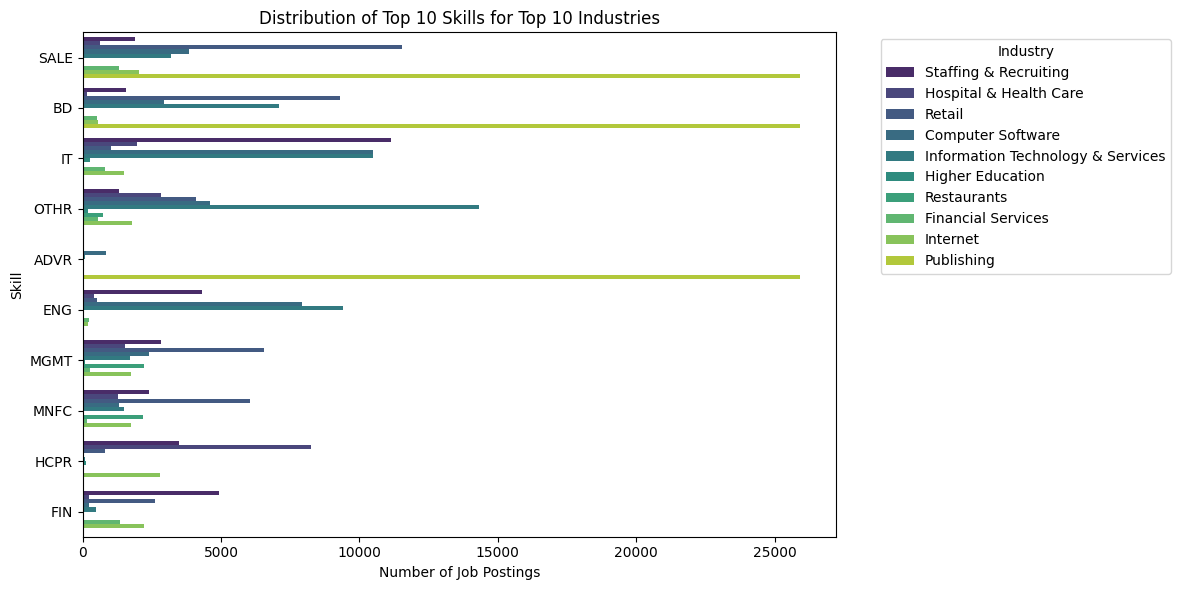

In [23]:
# Merge the skills_df and company_industries dataframes
skills_industry_df = pd.merge(skills_df, company_industries_df, left_on='company_id', right_on='company_id')

# Get the top 10 industries with the most job postings
top_industries = skills_industry_df['industry'].value_counts().head(10).index

# Filter the dataframe to only include the top 10 industries
top_industries_df = skills_industry_df[skills_industry_df['industry'].isin(top_industries)]

# Get the top 10 skills required for the top 10 industries
top_skills = top_industries_df['skill_abr'].value_counts().head(10).index

# Filter the dataframe to only include the top 10 skills
top_skills_df = top_industries_df[top_industries_df['skill_abr'].isin(top_skills)]

# Plot the distribution of skills for the top 10 industries
plt.figure(figsize=(12, 6))
sns.countplot(y='skill_abr', hue='industry', data=top_skills_df, order=top_skills, palette='viridis')
plt.title('Distribution of Top 10 Skills for Top 10 Industries')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**The bar chart shows the distribution of the top 10 skills required for the top 10 industries with the most job postings:**

* The most required skill for 'Information Technology & Services' industry is 'Information Technology', followed by 'Project Management' and 'Management'.
* The most required skill for 'Computer Software' industry is 'Software Development', followed by 'Information Technology' and 'Project Management'.
* The most required skill for 'Financial Services' industry is 'Finance', followed by 'Project Management' and 'Information Technology'.
* The distribution of skills varies significantly across different industries.